In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [90]:
df = pd.read_csv("loan_data.csv")

In [94]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  508 non-null    float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          836 non-null    float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    527 non-null    float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,DTI_Ratio_sq,Credit_Score_sq
count,1000.000000,508.000000,1000.000000,836.000000,1000.00000,1000.000000,1000.000000,1000.000000,5.270000e+02,1.000000e+03,1000.000000,1000.000000,1000.00000
mean,11.393430,49735.645669,40.671000,2.068182,600.10300,2.522000,0.404470,412294.272000,1.506048e+06,7.830521e+05,97.836000,0.192769,389276.44300
std,0.670127,29544.882501,11.763211,1.389918,170.82744,1.715943,0.170887,231111.877121,8.361295e+05,4.101824e+05,79.719862,0.140429,207181.69043
min,9.626152,11.000000,21.000000,0.000000,300.00000,0.000000,0.100000,5205.000000,5.038700e+04,5.241300e+04,12.000000,0.010000,90000.00000
25%,11.017725,24138.000000,30.000000,1.000000,455.75000,1.000000,0.260000,212309.500000,8.255350e+05,4.261032e+05,24.000000,0.067600,207708.25000
50%,11.564729,51186.500000,41.000000,2.000000,594.00000,3.000000,0.400000,404955.500000,1.482899e+06,7.880765e+05,60.000000,0.160000,352836.00000
75%,11.946663,75690.250000,51.000000,3.000000,754.00000,4.000000,0.550000,617724.000000,2.193310e+06,1.124552e+06,180.000000,0.302500,568516.00000
max,12.203865,99914.000000,60.000000,4.000000,900.00000,5.000000,0.700000,799573.000000,2.997957e+06,1.498084e+06,240.000000,0.490000,810000.00000


Handle Missing Data<!--  -->


In [95]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [96]:
from sklearn.impute import SimpleImputer

num_imp =  SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [97]:
cat_imp = SimpleImputer(strategy="most_frequent")

df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

df.isnull().sum()

 EDA - exploratory data analysis

Text(0.5, 1.0, 'Is loan Approved')

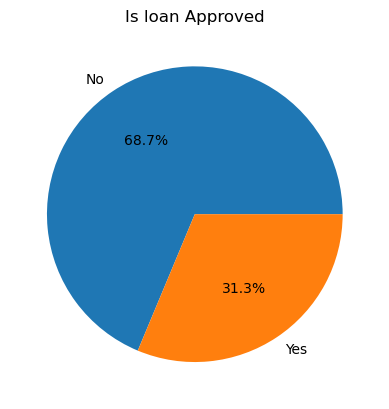

In [98]:
# how balanced our classes are?

classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"], autopct="%1.1f%%")
plt.title("Is loan Approved")

[Text(0, 0, '344'), Text(0, 0, '332'), Text(0, 0, '324')]

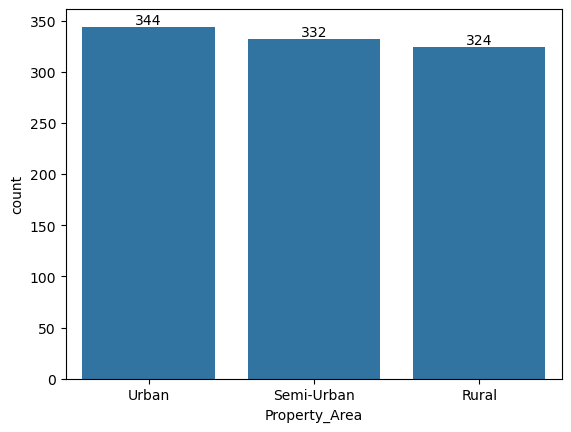

In [99]:
# analyze catagories
# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

# edu_cnt = df["Education_Level"].value_counts()
# ax = sns.barplot(edu_cnt)
# ax.bar_label(ax.containers[0])

pra_cnt = df["Property_Area"].value_counts()
ax = sns.barplot(pra_cnt)
ax.bar_label(ax.containers[0])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

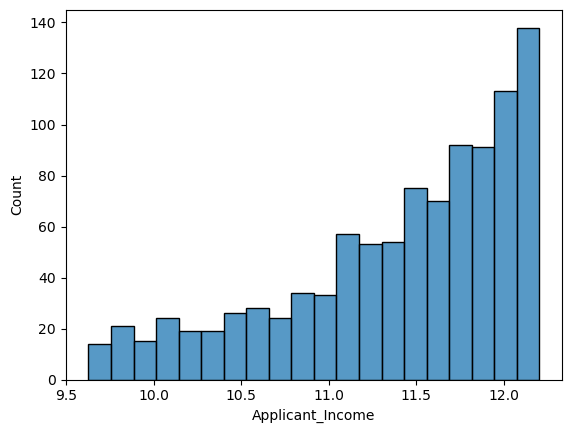

In [100]:
# analyze income
sns.histplot(
    data=df,
    x= "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

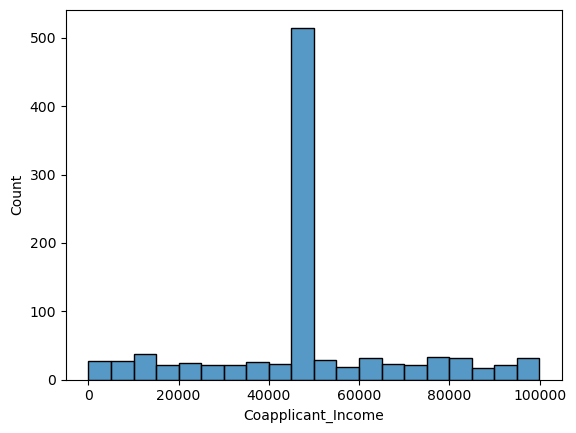

In [101]:
sns.histplot(
    data=df,
    x= "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

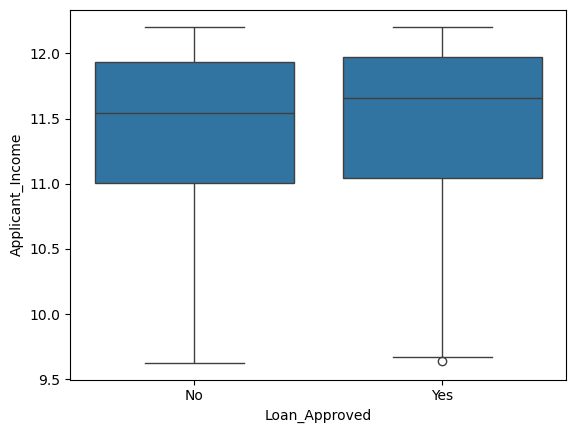

In [102]:
# outliers - boxplot
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income",
)

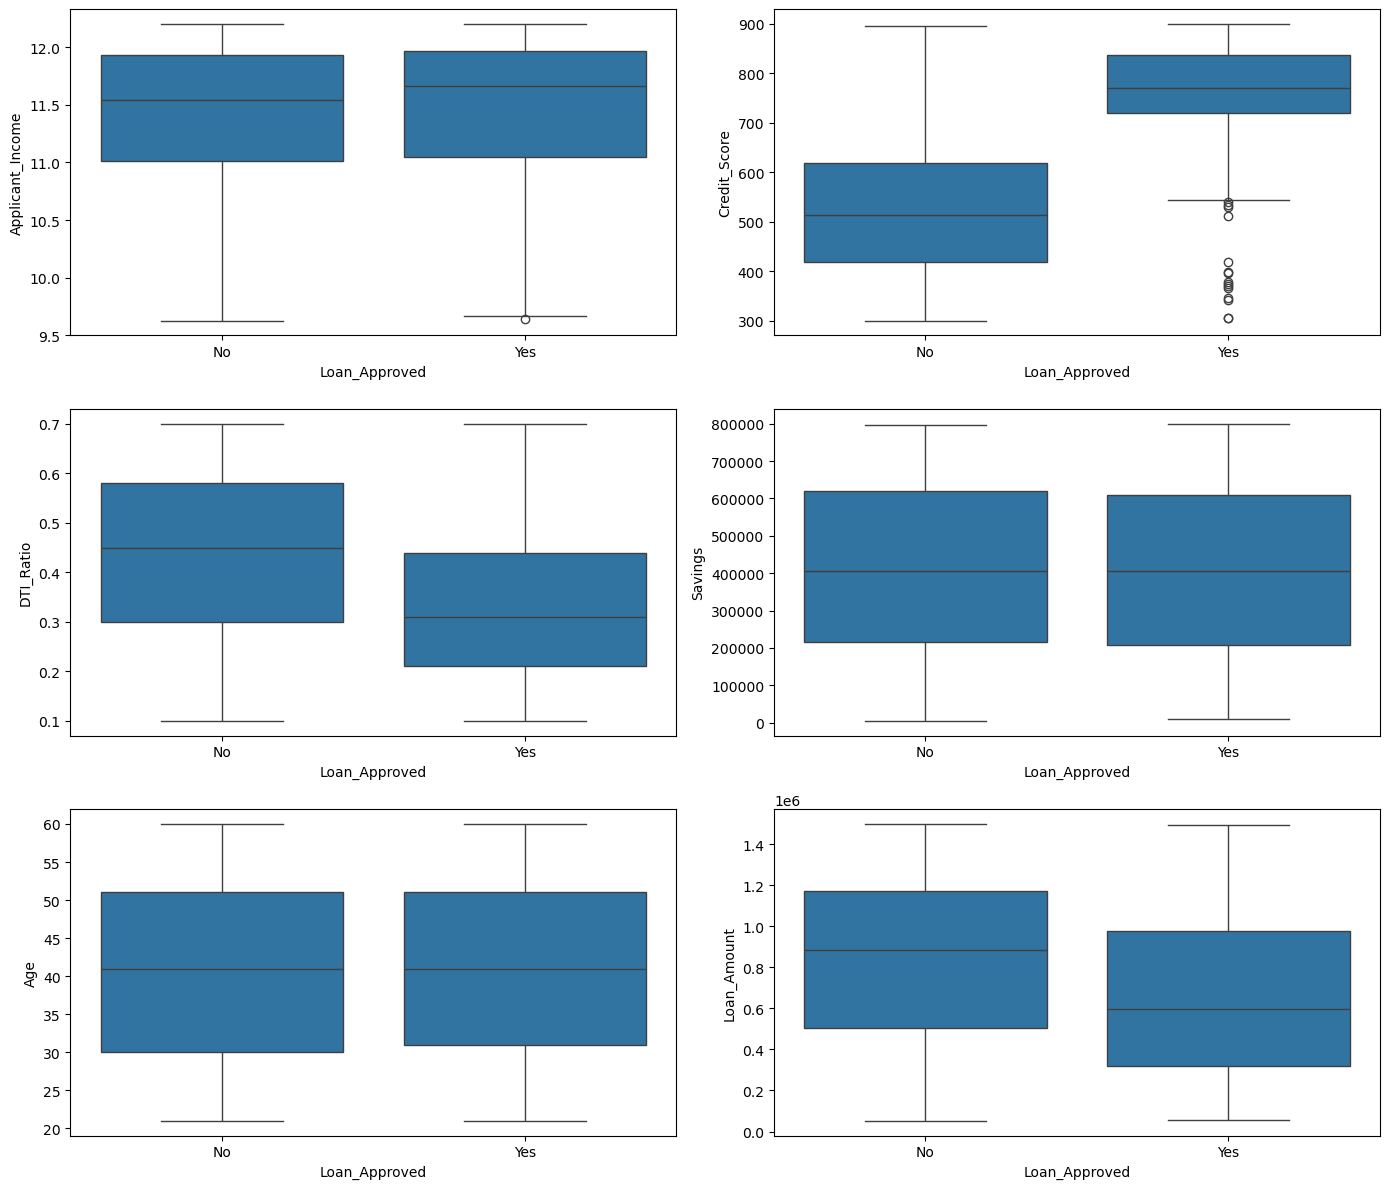

In [103]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

sns.boxplot(ax=axes[0,0], data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0], data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[2,0], data=df,x="Loan_Approved",y="Age",)
sns.boxplot(ax=axes[2,1], data=df,x="Loan_Approved",y="Loan_Amount",)

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

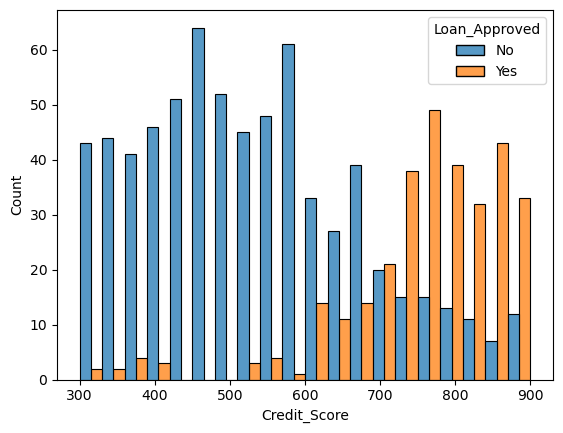

In [104]:
# credit score with loan approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

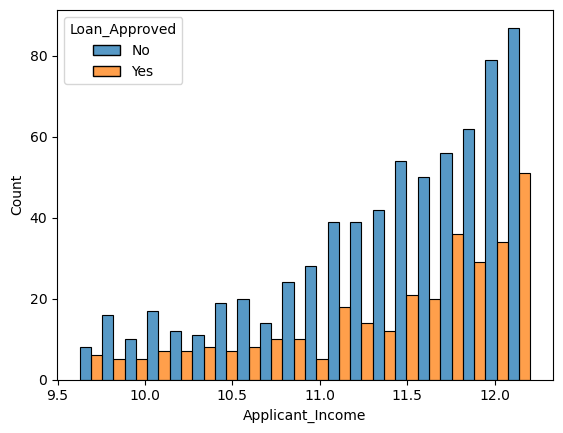

In [105]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [91]:
df = df.drop("Applicant_ID", axis=1)

In [106]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,...,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved,DTI_Ratio_sq,Credit_Score_sq
0,12.115168,14592.000000,Salaried,35.0,Married,0.000000,581.0,1.0,0.45,777246.0,...,342632.0,24.0,Education,Rural,Undergraduate,Male,Self,No,0.2025,337561.0
1,11.114297,49735.645669,Salaried,58.0,Married,2.000000,525.0,3.0,0.30,11814.0,...,633408.0,12.0,Home,Semi-Urban,Graduate,Female,Private,No,0.0900,275625.0
2,12.062566,34671.000000,Business,28.0,Single,4.000000,770.0,4.0,0.60,87627.0,...,843844.0,24.0,Home,Urban,Undergraduate,Male,Private,Yes,0.3600,592900.0
3,10.488938,30512.000000,Business,50.0,Single,2.068182,689.0,2.0,0.31,387554.0,...,1383126.0,180.0,Home,Rural,Undergraduate,Male,Self,No,0.0961,474721.0
4,11.279416,49735.645669,Salaried,56.0,Single,3.000000,688.0,2.0,0.24,722870.0,...,510566.0,36.0,Home,Urban,Undergraduate,Female,Govt,No,0.0576,473344.0


Encoding

In [107]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [47]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,182621.0,14592.000000,Salaried,35.0,Married,0.000000,581.0,1.0,0.45,777246.0,4.798950e+05,342632.0,24.0,Education,Rural,2,Male,Self,0
1,67124.0,49735.645669,Salaried,58.0,Married,2.000000,525.0,3.0,0.30,11814.0,1.506048e+06,633408.0,12.0,Home,Semi-Urban,0,Female,Private,0
2,173263.0,34671.000000,Business,28.0,Single,4.000000,770.0,4.0,0.60,87627.0,1.506048e+06,843844.0,24.0,Home,Urban,2,Male,Private,1
3,35916.0,30512.000000,Business,50.0,Single,2.068182,689.0,2.0,0.31,387554.0,1.506048e+06,1383126.0,180.0,Home,Rural,2,Male,Self,0
4,79175.0,49735.645669,Salaried,56.0,Single,3.000000,688.0,2.0,0.24,722870.0,1.410140e+06,510566.0,36.0,Home,Urban,2,Female,Govt,0


In [108]:
cols = ["Employment_Status", "Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols),index=df.index)

df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [109]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semi-Urban,Property_Area_Urban,Gender_Male,Employer_Category_Private,Employer_Category_Self
0,12.115168,14592.000000,35.0,0.000000,581.0,1.0,0.45,777246.0,4.798950e+05,342632.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,11.114297,49735.645669,58.0,2.000000,525.0,3.0,0.30,11814.0,1.506048e+06,633408.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,12.062566,34671.000000,28.0,4.000000,770.0,4.0,0.60,87627.0,1.506048e+06,843844.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3,10.488938,30512.000000,50.0,2.068182,689.0,2.0,0.31,387554.0,1.506048e+06,1383126.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,11.279416,49735.645669,56.0,3.000000,688.0,2.0,0.24,722870.0,1.410140e+06,510566.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,11.335997,64164.000000,56.0,2.068182,508.0,5.0,0.56,366766.0,1.516080e+05,1021371.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
996,11.503965,49735.645669,38.0,1.000000,875.0,5.0,0.62,147256.0,1.639262e+06,1064672.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,12.141033,72587.000000,24.0,3.000000,404.0,3.0,0.49,195476.0,1.893549e+06,1202120.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
998,12.137837,76356.000000,32.0,2.068182,329.0,2.0,0.54,167730.0,2.468637e+06,411850.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


df.info()

Corelation Heatmap

<Axes: >

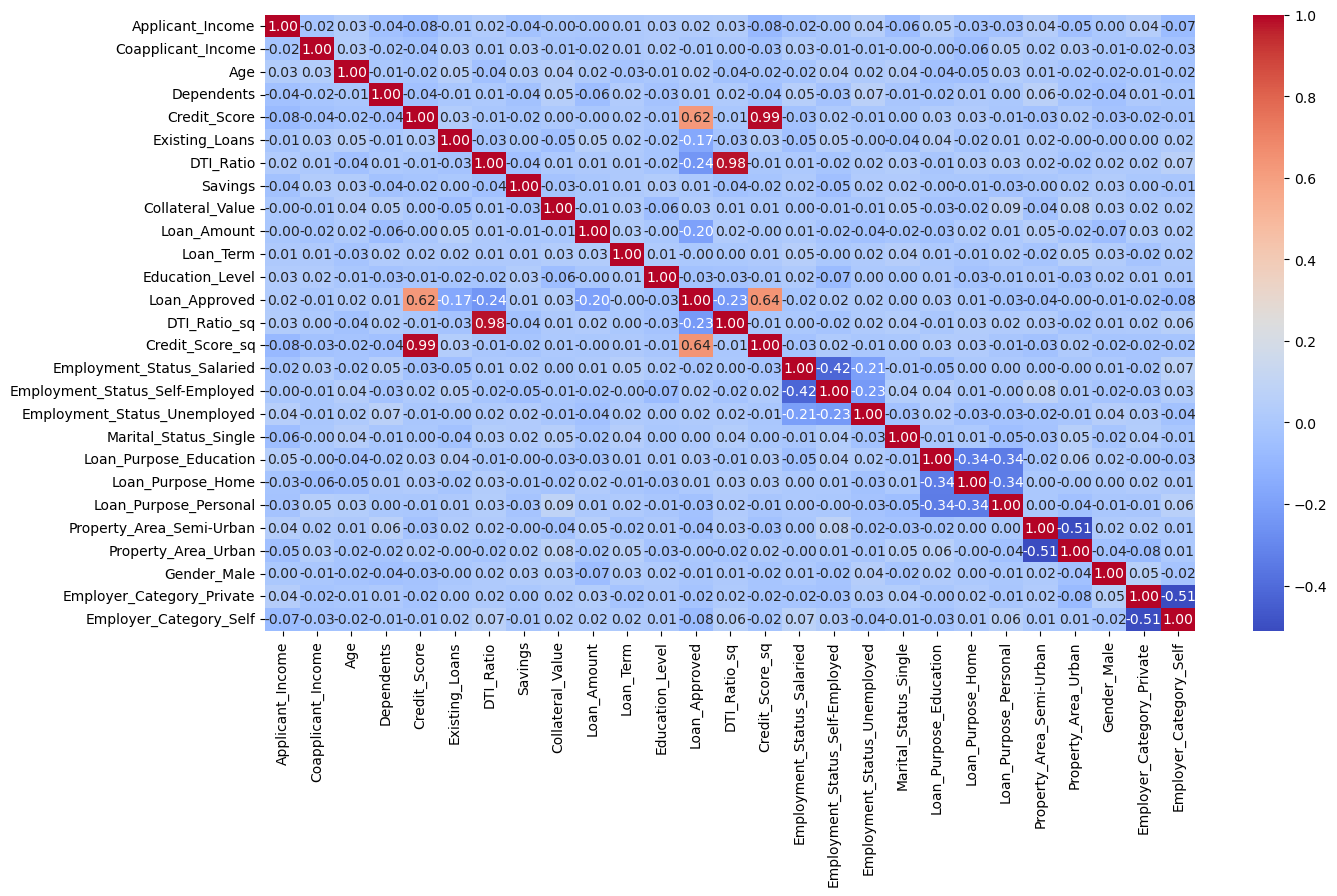

In [110]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [60]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.624243
Applicant_Income                   0.041134
Collateral_Value                   0.031165
Loan_Purpose_Education             0.025249
Age                                0.022740
Employment_Status_Self-Employed    0.020450
Employment_Status_Unemployed       0.019409
Dependents                         0.013043
Savings                            0.007117
Loan_Purpose_Home                  0.005863
Marital_Status_Single              0.003506
Loan_Term                         -0.002562
Property_Area_Urban               -0.003051
Coapplicant_Income                -0.005070
Gender_Male                       -0.011195
Employment_Status_Salaried        -0.016344
Employer_Category_Private         -0.023693
Loan_Purpose_Personal             -0.033289
Education_Level                   -0.034346
Property_Area_Semi-Urban          -0.040828
Employer_Category_Self            -0.075625
Existing_Loans                  

Train_Test_Split + Feature Scaling

In [62]:
x = df.drop("Loan_Approved",axis=1)
y = df["Loan_Approved"]

In [63]:
x.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semi-Urban,Property_Area_Urban,Gender_Male,Employer_Category_Private,Employer_Category_Self
0,182621.0,14592.000000,35.0,0.000000,581.0,1.0,0.45,777246.0,4.798950e+05,342632.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,67124.0,49735.645669,58.0,2.000000,525.0,3.0,0.30,11814.0,1.506048e+06,633408.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,173263.0,34671.000000,28.0,4.000000,770.0,4.0,0.60,87627.0,1.506048e+06,843844.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
3,35916.0,30512.000000,50.0,2.068182,689.0,2.0,0.31,387554.0,1.506048e+06,1383126.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,79175.0,49735.645669,56.0,3.000000,688.0,2.0,0.24,722870.0,1.410140e+06,510566.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [64]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [65]:
x_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semi-Urban,Property_Area_Urban,Gender_Male,Employer_Category_Private,Employer_Category_Self
29,86228.0,49735.645669,29.0,3.000000,853.0,0.0,0.52,247495.0,1.656566e+06,366314.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
535,62362.0,49735.645669,29.0,4.000000,788.0,4.0,0.49,14958.0,2.930053e+06,593290.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
695,51811.0,49735.645669,33.0,0.000000,723.0,1.0,0.26,213902.0,1.506048e+06,622101.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
557,128745.0,48318.000000,52.0,2.068182,790.0,0.0,0.21,486705.0,8.260630e+05,430661.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
836,23178.0,81169.000000,21.0,2.068182,311.0,2.0,0.16,471679.0,1.649795e+06,686373.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [78]:
x_test_scaled

array([[ 1.54915695,  2.01790471,  1.06418188, ...,  0.95118973,
        -0.72977192,  1.42488702],
       [-1.64665228,  0.01379899,  0.22417645, ...,  0.95118973,
         1.37029115, -0.70181003],
       [-1.31570593,  0.01379899,  1.4841846 , ...,  0.95118973,
        -0.72977192, -0.70181003],
       ...,
       [-1.10355136,  0.5780403 ,  1.65218568, ..., -1.05131497,
         1.37029115, -0.70181003],
       [-1.35514303,  0.95959373,  1.65218568, ..., -1.05131497,
        -0.72977192,  1.42488702],
       [ 1.13310853,  0.01379899,  0.72817971, ..., -1.05131497,
        -0.72977192, -0.70181003]], shape=(200, 24))

Train & Evaluate Models

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)

y_pred = log_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.7580645161290323
Recall: 0.8103448275862069
F1 score: 0.7833333333333333
Accuracy: 0.87
CM: [[127  15]
 [ 11  47]]


In [85]:
# knn
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)

y_pred = knn_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.6590909090909091
Recall: 0.5
F1 score: 0.5686274509803921
Accuracy: 0.78
CM: [[127  15]
 [ 29  29]]


In [86]:
# naive bayes
from sklearn.naive_bayes import GaussianNB

nb_model =GaussianNB()
nb_model.fit(x_train_scaled,y_train)

y_pred = nb_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.7619047619047619
Recall: 0.8275862068965517
F1 score: 0.7933884297520661
Accuracy: 0.875
CM: [[127  15]
 [ 10  48]]


In [111]:
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
df["Applicant_Income"] = np.log(df["Applicant_Income"])

x= df.drop(columns=["Loan_Approved","DTI_Ratio","Credit_Score","Applicant_Income"])
y = df["Loan_Approved"]

# training
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)

# scalining
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [112]:
log_model = LogisticRegression()
log_model.fit(x_train_scaled,y_train)

y_pred = log_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.7719298245614035
Recall: 0.7586206896551724
F1 score: 0.7652173913043478
Accuracy: 0.865
CM: [[129  13]
 [ 14  44]]


In [113]:
# knn
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)

y_pred = knn_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.6590909090909091
Recall: 0.5
F1 score: 0.5686274509803921
Accuracy: 0.78
CM: [[127  15]
 [ 29  29]]


In [114]:
nb_model =GaussianNB()
nb_model.fit(x_train_scaled,y_train)

y_pred = nb_model.predict(x_test_scaled)

#Evaluate matrix
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 score:",f1_score(y_test,y_pred))
print("Accuracy:",accuracy_score(y_test,y_pred))
print("CM:",confusion_matrix(y_test,y_pred))

Precision: 0.8070175438596491
Recall: 0.7931034482758621
F1 score: 0.8
Accuracy: 0.885
CM: [[131  11]
 [ 12  46]]
